<a href="https://colab.research.google.com/github/cailyx/polyadenylation/blob/main/main_for_urop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_9919/3498808261.py:13: RuntimeWarning: divide by zero encountered in log
  e = 5*np.log(3*n) - 5*np.log(750) #entropy increases logarithmically
/tmp/ipykernel_9919/3498808261.py:16: RuntimeWarning: divide by zero encountered in log
  e_salt = 6*np.log(1.5*n) - 6*np.log(750)


([<matplotlib.axis.XTick at 0x7d8edf124e00>,
 [Text(0, 0, '0'),
  Text(50, 0, '50'),
  Text(100, 0, '100'),
  Text(150, 0, '150'),
  Text(200, 0, '200'),
  Text(250, 0, '250'),
  Text(300, 0, '300'),
  Text(350, 0, '350'),
  Text(400, 0, '400'),
  Text(450, 0, '450'),
  Text(500, 0, '500'),
  Text(550, 0, '550')])

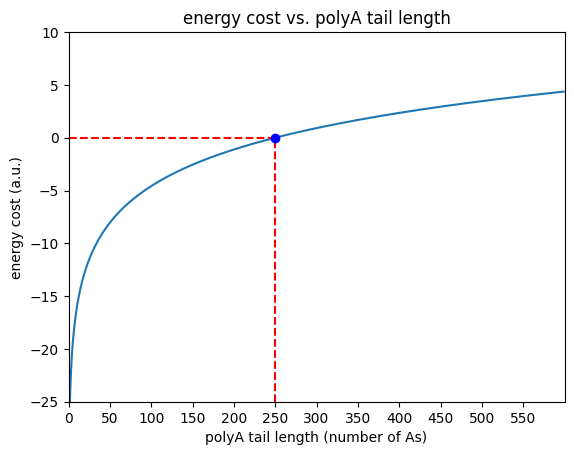

In [ ]:
#motivation

import matplotlib.pyplot as plt
import numpy as np

#generate a range of values for x-axis (num A)
numA = np.arange(0,600)

all_e = []
all_e_salt = []

for n in numA:
  e = 5*np.log(3*n) - 5*np.log(750) #entropy increases logarithmically
  all_e.append(e)

  e_salt = 6*np.log(1.5*n) - 6*np.log(750)
  all_e_salt.append(e_salt)

e_250 = 0

#plot E vs num A , along with a horizontal, vertical line at x=250, y=f(250)
plt.plot(numA, all_e)
#plt.plot(numA, all_e_salt)
#plt.axhline(y=e_250, color='r', linestyle='--')
plt.hlines(y=0,xmin=0,xmax=250,color='red',linestyle='--')
plt.vlines(x=250, ymin=-25, ymax=0, color = 'red', linestyle = '--')
#plt.vlines(x=750/1.5, ymin=-25, ymax=0, color = 'red', linestyle = '--')
#plt.plot([250, 750/1.5], [e_250, e_250], 'bo')
plt.plot(250,0,'bo')
plt.xlabel('polyA tail length (number of As)')
plt.ylabel('energy cost (a.u.)')
plt.title('energy cost vs. polyA tail length')
plt.ylim(-25,10)
plt.xlim(0,600)
plt.xticks(np.arange(0, 600, 50))


/tmp/ipykernel_9919/2889889433.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  l_p = l_p_base/s


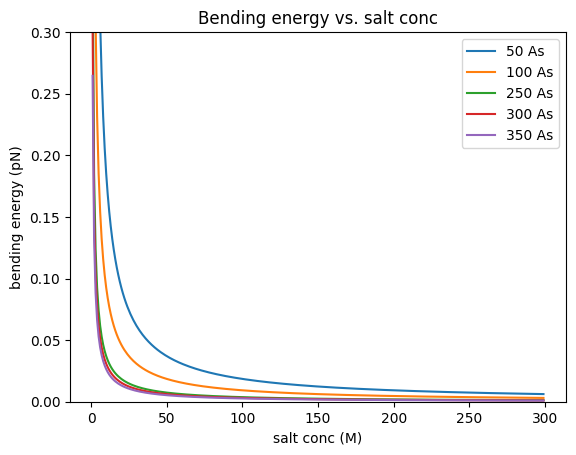

In [ ]:
##goal- plot bending energy as a function of [salt]
## do for a handful of tail lengths (50, 100, 250, 300, 350) as different lines.
#f(g(salt)) = bending energy
  #g(salt) = l_p
  #f(l_p) = bending energy

import matplotlib.pyplot as plt
import numpy as np

#constants
l_p_base = 8 #nm

salt_concs = np.arange(0,300)
numA = 50 #change
numA_list = [50, 100, 250, 300, 350]
d_A = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.

for A in numA_list:
  e_bend_values = []

  for s in salt_concs:
    l_p = l_p_base/s
    k_b = l_p*4.1 #k_b is bending rigidity, 4.1 pN = kB*T
    r = (A)/2/np.pi
    e_bend = ((np.pi*k_b)/r)*0.143

    e_bend_values.append(e_bend)

  plt.plot(salt_concs, e_bend_values, label = str(A) + ' As')
  plt.xlabel('salt conc (M)')
  plt.ylabel('bending energy (pN)')
  plt.title('Bending energy vs. salt conc')
  plt.legend()
  plt.ylim(0,0.3)


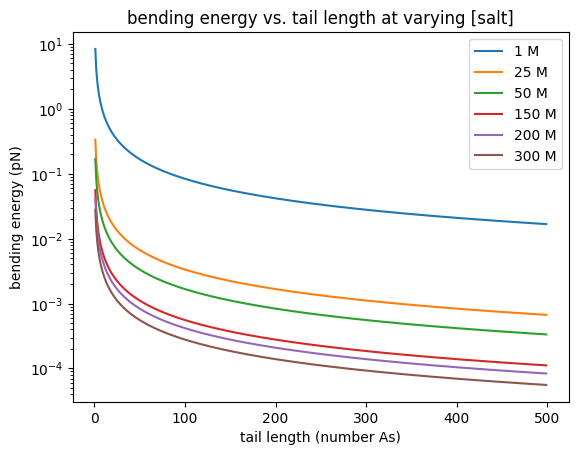

In [ ]:
##goal- plot bending energy as a function of tail length
## do for a handful of [salt]'s as different lines.
#f(g(salt)) = bending energy
  #g(salt) = l_p
  #f(l_p) = bending energy

import matplotlib.pyplot as plt
import numpy as np

#constants
l_p_base = 2 #nm

salt_concs = [1, 25, 50, 150, 200, 300]
numA = 50 #change
numA_list = np.arange(1,500)
d_A = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.

for s in salt_concs:
  e_bend_values = []

  for A in numA_list:
    l_p = l_p_base/s
    k_b = l_p*4.1 #k_b is bending rigidity, 4.1 pN = kB*T
    r = (A*d_A)/2/np.pi
    e_bend = ((np.pi*k_b)/r)*0.143

    e_bend_values.append(e_bend)

  plt.plot(numA_list, e_bend_values, label = str(s) + ' M')
  plt.xlabel('tail length (number As)')
  plt.ylabel('bending energy (pN)')
  plt.title('bending energy vs. tail length at varying [salt]')
  plt.legend()
  plt.yscale('log')

In [ ]:
#goal- plot how persistence length changes with salt
#l_p of a charged polymer described by the OSF-Odijk, Skolnick, Fixman- model.


